In [1]:
# Import required libraries for data handling, modeling, and visualization
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix

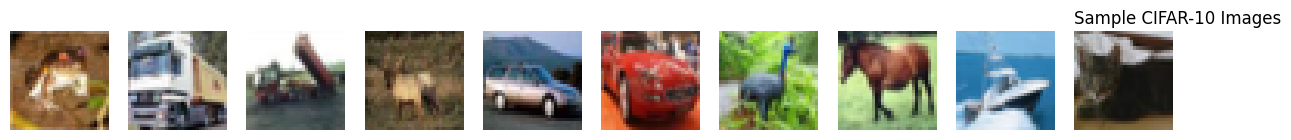

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 10)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 10)


In [2]:
# Define the path to your extracted dataset folder
data_dir = '/kaggle/input/datasets/kamleshdllab/cifar-dataset/cifar-10-batches-py'

# Function to unpickle and reshape a single CIFAR-10 batch
def load_cifar_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    # Reshape from flat array to (batch, channels, height, width), then transpose to (batch, height, width, channels)
    features = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = batch[b'labels']
    return features, labels

# Load and combine all 5 training batches
x_train, y_train = [], []
for i in range(1, 6):
    x_batch, y_batch = load_cifar_batch(os.path.join(data_dir, f'data_batch_{i}'))
    x_train.append(x_batch)
    y_train.extend(y_batch)
x_train = np.concatenate(x_train)
y_train = np.array(y_train)

# Load the testing batch
x_test, y_test = load_cifar_batch(os.path.join(data_dir, 'test_batch'))
y_test = np.array(y_test)

# Normalize pixel values to the range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert integer labels to one-hot encoded vectors
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Display 10 sample images from the training set
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.title("Sample CIFAR-10 Images", loc='left')
plt.show()

# Print the dimensions of the datasets
print(f"Training data shape: {x_train.shape}, Training labels shape: {y_train_cat.shape}")
print(f"Testing data shape: {x_test.shape}, Testing labels shape: {y_test_cat.shape}")

In [3]:
# Load pre-trained MobileNetV2 without original classification head
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the convolutional base to keep pre-trained weights fixed
base_model.trainable = False

# Add global pooling and dense layers for 10 CIFAR-10 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

# Construct and compile the model with LR 0.001
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train for 10 epochs
print("Starting initial training (10 epochs)...")
history_initial = model.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

/tmp/ipykernel_23/364830647.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
I0000 00:00:1788087494.369695      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788087494.372599      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting initial training (10 epochs)...
Epoch 1/10


2026-08-30 10:58:32.740474: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 10:58:32.876004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788087514.592965      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1559/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2658 - loss: 2.0163

2026-08-30 10:58:50.199906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 10:58:50.335194: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.2998 - loss: 1.9294 - val_accuracy: 0.3250 - val_loss: 1.8626
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3366 - loss: 1.8270 - val_accuracy: 0.3387 - val_loss: 1.8242
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3503 - loss: 1.7884 - val_accuracy: 0.3449 - val_loss: 1.8107
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3618 - loss: 1.7604 - val_accuracy: 0.3484 - val_loss: 1.8013
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3693 - loss: 1.7383 - val_accuracy: 0.3511 - val_loss: 1.8003
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3741 - loss: 1.7199 - val_accuracy: 0.3520 - val_loss: 1.7940
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3806 - loss: 1.7036 - val_accuracy: 0.3505 - val_loss: 1.7942
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3884 - loss: 1.6885 - va

In [4]:
# Unfreeze base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last 15 layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

# Recompile using Adam optimizer with LR 0.001
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train fine-tuning stage for 10 epochs
print("Starting fine-tuning (10 epochs)...")
history_fine = model.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

# Extract and compare validation accuracy before and after fine-tuning
acc_before = history_initial.history['val_accuracy'][-1] * 100
acc_after = history_fine.history['val_accuracy'][-1] * 100

# Print explicit numerical comparison
print(f"Validation Accuracy Before Fine-Tuning: {acc_before:.2f}%")
print(f"Validation Accuracy After Fine-Tuning:  {acc_after:.2f}%")
print(f"Improvement: {acc_after - acc_before:+.2f}%")

Starting fine-tuning (10 epochs)...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.4141 - loss: 2.0838 - val_accuracy: 0.2878 - val_loss: 2.5048
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5201 - loss: 1.3759 - val_accuracy: 0.4182 - val_loss: 1.7693
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5490 - loss: 1.2934 - val_accuracy: 0.5106 - val_loss: 1.4558
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5690 - loss: 1.2400 - val_accuracy: 0.5498 - val_loss: 1.4313
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5859 - loss: 1.1938 - val_accuracy: 0.5277 - val_loss: 1.4128
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6012 - loss: 1.1497 - val_accuracy: 0.5304 - val_loss: 1.4858
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6183 - loss: 1.1072 - val_accuracy: 0.5494 - val_loss: 1.3957
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.38      0.52      1000
           1       0.47      0.84      0.60      1000
           2       0.55      0.41      0.47      1000
           3       0.57      0.34      0.43      1000
           4       0.33      0.86      0.47      1000
           5       0.62      0.48      0.54      1000
           6       0.81      0.53      0.64      1000
           7       0.78      0.39      0.52      1000
           8       0.65      0.60      0.62      1000
           9       0.72      0.63      0.67      1000

    accuracy                           0.55     10000
   macro avg       0.63      0.55      0.55     10000
weighted avg       0.63      0.55      0.55     10000



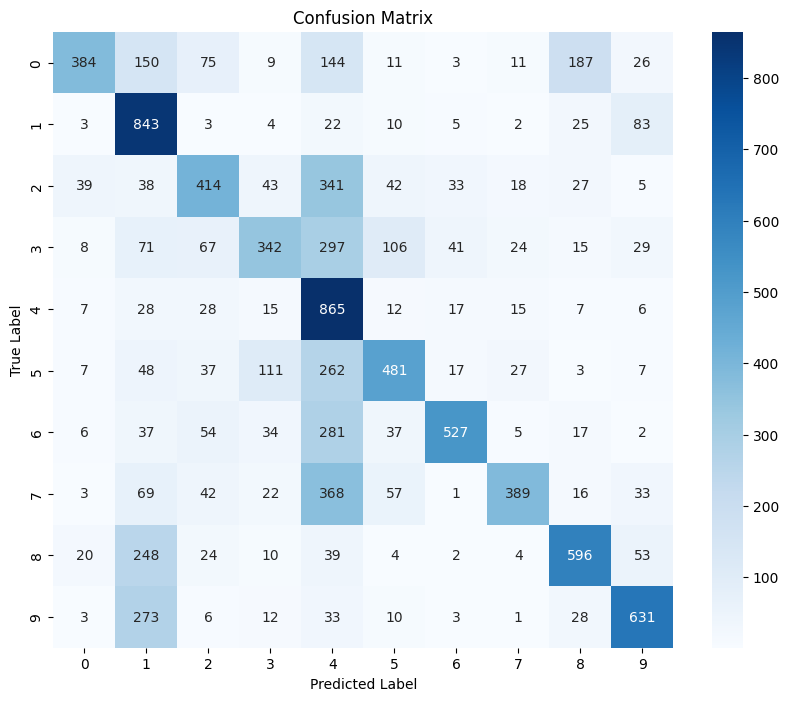

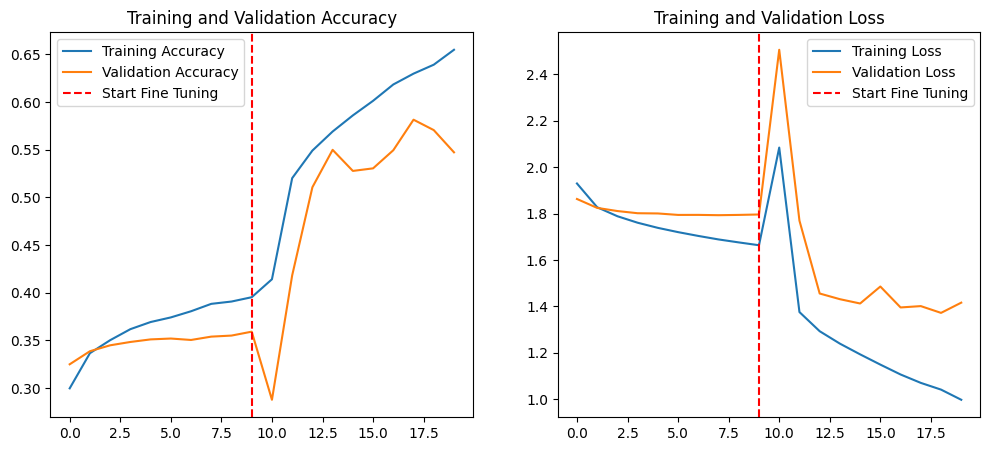

In [5]:
# Generate predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Print Classification Report (Accuracy, Precision, Recall, F1)
print("\nClassification Report:\n", classification_report(y_true_classes, y_pred_classes))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Combine histories for plotting accuracy and loss curves
acc = history_initial.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_initial.history['loss'] + history_fine.history['loss']
val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

# Plot Training & Validation Accuracy and Loss
plt.figure(figsize=(12, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='r', linestyle='--', label='Start Fine Tuning')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=9, color='r', linestyle='--', label='Start Fine Tuning')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [6]:
import random
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam, SGD

# Define the hyperparameter search space from Task 16
param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [16, 32, 64],
    'epochs': [10, 20],
    'optimizer_name': ['Adam', 'SGD'],
    'dense_units': [128, 256],
    'freeze_all': [True, False]
}

# Function to build, train, and evaluate a single model configuration
def evaluate_config(learning_rate, batch_size, epochs, optimizer_name, dense_units, freeze_all):
    # Load base model
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = not freeze_all
    
    # Freeze initial layers if partial fine-tuning is selected
    if not freeze_all:
        for layer in base.layers[:-15]:
            layer.trainable = False

    # Attach classification head
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(dense_units, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=out)
    
    # Select optimizer
    opt = Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else SGD(learning_rate=learning_rate)
    
    # Compile and train
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.2, verbose=0)
    
    # Evaluate test accuracy
    _, acc = model.evaluate(x_test, y_test_cat, verbose=0)
    return acc

# Function to run automated randomized hyperparameter search
def randomized_search(n_iter=6):
    results = []
    
    # Generate all possible parameter combinations
    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    # Sample unique random configurations
    sampled_configs = random.sample(all_combinations, min(n_iter, len(all_combinations)))
    
    print(f"Starting Randomized Search for {len(sampled_configs)} iterations...\n")
    
    for i, config in enumerate(sampled_configs, start=1):
        print(f"[Trial {i}/{len(sampled_configs)}] Testing: {config}")
        test_acc = evaluate_config(**config)
        config['test_accuracy'] = round(test_acc * 100, 2)
        config['frozen_layers'] = 'All' if config.pop('freeze_all') else 'Partial'
        results.append(config)
        print(f"--> Test Accuracy: {config['test_accuracy']}%\n")
    
    # Format results into a comparison dataframe
    df_results = pd.DataFrame(results)
    return df_results

# Execute randomized search over 6 iterations
import itertools
tuning_results = randomized_search(n_iter=6)
display(tuning_results)

Starting Randomized Search for 6 iterations...

[Trial 1/6] Testing: {'learning_rate': 0.001, 'batch_size': 16, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 128, 'freeze_all': True}


/tmp/ipykernel_23/1222883352.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


--> Test Accuracy: 34.59%

[Trial 2/6] Testing: {'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 20, 'optimizer_name': 'Adam', 'dense_units': 128, 'freeze_all': True}
--> Test Accuracy: 33.52%

[Trial 3/6] Testing: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze_all': True}


2026-08-30 11:08:58.593946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:08:58.730566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


--> Test Accuracy: 35.1%

[Trial 4/6] Testing: {'learning_rate': 0.001, 'batch_size': 16, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze_all': False}
--> Test Accuracy: 59.15%

[Trial 5/6] Testing: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 10, 'optimizer_name': 'SGD', 'dense_units': 128, 'freeze_all': True}
--> Test Accuracy: 22.46%

[Trial 6/6] Testing: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze_all': False}
--> Test Accuracy: 56.73%



,learning_rate,batch_size,epochs,optimizer_name,dense_units,test_accuracy,frozen_layers
0,0.0010,16,10,Adam,128,34.59,All
1,0.0001,32,20,Adam,128,33.52,All
2,0.0010,64,20,Adam,256,35.10,All
3,0.0010,16,10,Adam,256,59.15,Partial
4,0.0010,64,10,SGD,128,22.46,All
5,0.0010,32,10,Adam,256,56.73,Partial


In [7]:
# Import VGG16 architecture
from tensorflow.keras.applications import VGG16

# Load pre-trained VGG16 without classification head
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze all layers of the VGG16 base
vgg_base.trainable = False

# Construct custom classification layers
x = GlobalAveragePooling2D()(vgg_base.output)
x = Dense(128, activation='relu')(x)
vgg_out = Dense(10, activation='softmax')(x)
vgg_model = Model(inputs=vgg_base.input, outputs=vgg_out)

# Compile VGG16 model
vgg_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train VGG16 model on CIFAR-10
print("Training VGG16...")
vgg_history = vgg_model.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

# Evaluate VGG16 test accuracy
vgg_loss, vgg_acc = vgg_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"VGG16 Test Accuracy: {vgg_acc * 100:.2f}%")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training VGG16...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.5243 - loss: 1.3676 - val_accuracy: 0.5656 - val_loss: 1.2440
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5853 - loss: 1.1874 - val_accuracy: 0.5799 - val_loss: 1.2065
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6042 - loss: 1.1316 - val_accuracy: 0.5876 - val_loss: 1.1807
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6189 - loss: 1.0907 - val_accuracy: 0.5890 - val_loss: 1.1765
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6290 - loss: 1.0580 - val_accuracy: 0.5878 - val_loss: 1.1749
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6388 - loss: 1.0290 - val_accuracy: 0.6017 - val_loss: 1.1378
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6502 - loss: 1.0020 - val_accuracy: 0.6095 - val_loss: 1.1271
Epoch 8/10
15

In [8]:
# Import ResNet50 architecture
from tensorflow.keras.applications import ResNet50

# Load pre-trained ResNet50 without classification head
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze all layers of the ResNet50 base
resnet_base.trainable = False

# Construct custom classification layers
x = GlobalAveragePooling2D()(resnet_base.output)
x = Dense(128, activation='relu')(x)
resnet_out = Dense(10, activation='softmax')(x)
resnet_model = Model(inputs=resnet_base.input, outputs=resnet_out)

# Compile ResNet50 model
resnet_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train ResNet50 model on CIFAR-10
print("Training ResNet50...")
resnet_history = resnet_model.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

# Evaluate ResNet50 test accuracy
resnet_loss, resnet_acc = resnet_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"ResNet50 Test Accuracy: {resnet_acc * 100:.2f}%")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training ResNet50...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.2483 - loss: 2.0475 - val_accuracy: 0.3096 - val_loss: 1.9177
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3129 - loss: 1.8861 - val_accuracy: 0.3449 - val_loss: 1.8350
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3406 - loss: 1.8228 - val_accuracy: 0.3639 - val_loss: 1.7674
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3555 - loss: 1.7889 - val_accuracy: 0.3621 - val_loss: 1.7753
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3651 - loss: 1.7610 - val_accuracy: 0.3781 - val_loss: 1.7262
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3730 - loss: 1.7455 - val_accuracy: 0.3689 - val_loss: 1.7469
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3821 - loss: 1.7222 - val_accuracy: 0.3845 - val_loss: 1.6892
Epoch 8/10

/tmp/ipykernel_23/1064920736.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


Training with Adam...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.3024 - loss: 1.9306 - val_accuracy: 0.3215 - val_loss: 1.8678
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3335 - loss: 1.8301 - val_accuracy: 0.3350 - val_loss: 1.8323
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3461 - loss: 1.7904 - val_accuracy: 0.3421 - val_loss: 1.8094
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3601 - loss: 1.7617 - val_accuracy: 0.3511 - val_loss: 1.8002
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3679 - loss: 1.7395 - val_accuracy: 0.3493 - val_loss: 1.7938
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3740 - loss: 1.7209 - val_accuracy: 0.3537 - val_loss: 1.7921
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3822 - loss: 1.7051 - val_accuracy: 0.3554 - val_loss: 1.7892
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc

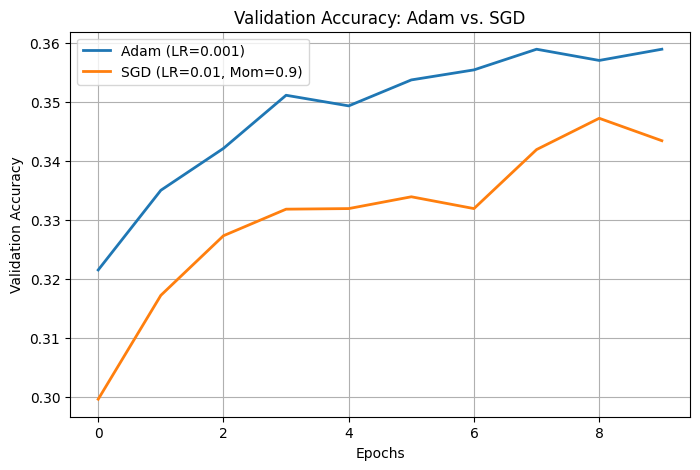

In [9]:
# Helper function to build a standardized MobileNetV2 feature extractor
def build_feature_extractor():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)

# Train model with Adam optimizer
model_adam = build_feature_extractor()
model_adam.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print("Training with Adam...")
history_adam = model_adam.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

# Train model with SGD optimizer
model_sgd = build_feature_extractor()
model_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
print("Training with SGD...")
history_sgd = model_sgd.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat))

# Plot validation accuracy comparison between Adam and SGD
plt.figure(figsize=(8, 5))
plt.plot(history_adam.history['val_accuracy'], label='Adam (LR=0.001)', linewidth=2)
plt.plot(history_sgd.history['val_accuracy'], label='SGD (LR=0.01, Mom=0.9)', linewidth=2)
plt.title('Validation Accuracy: Adam vs. SGD')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Import precision, recall, and f1 score functions from sklearn
from sklearn.metrics import precision_recall_fscore_support

# Evaluate purely frozen model
y_pred_frozen = np.argmax(model_adam.predict(x_test), axis=1)
y_true = np.argmax(y_test_cat, axis=1)
p_f, r_f, f1_f, _ = precision_recall_fscore_support(y_true, y_pred_frozen, average='macro')
loss_f, acc_f = model_adam.evaluate(x_test, y_test_cat, verbose=0)

# Unfreeze all layers in the model
for layer in model_adam.layers:
    layer.trainable = True

# Freeze all layers except the last 15 layers
for layer in model_adam.layers[:-15]:
    layer.trainable = False

# Recompile and fine-tune with a lower learning rate
model_adam.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
print("Fine-tuning model...")
model_adam.fit(x_train, y_train_cat, batch_size=32, epochs=5, validation_data=(x_test, y_test_cat))

# Evaluate fine-tuned model
y_pred_tuned = np.argmax(model_adam.predict(x_test), axis=1)
p_t, r_t, f1_t, _ = precision_recall_fscore_support(y_true, y_pred_tuned, average='macro')
loss_t, acc_t = model_adam.evaluate(x_test, y_test_cat, verbose=0)

# Display tabular comparison of frozen vs fine-tuned stages
print("\n" + "="*55)
print(f"{'Metric':<20}{'Frozen Base':<18}{'Fine-Tuned':<18}")
print("="*55)
print(f"{'Accuracy':<20}{acc_f*100:<18.2f}{acc_t*100:<18.2f}")
print(f"{'Precision (Macro)':<20}{p_f:<18.4f}{p_t:<18.4f}")
print(f"{'Recall (Macro)':<20}{r_f:<18.4f}{r_t:<18.4f}")
print(f"{'F1-Score (Macro)':<20}{f1_f:<18.4f}{f1_t:<18.4f}")
print("="*55)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
Fine-tuning model...
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.3274 - loss: 5.3228 - val_accuracy: 0.2547 - val_loss: 2.8786
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4237 - loss: 1.9856 - val_accuracy: 0.4257 - val_loss: 1.8672
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4808 - loss: 1.6495 - val_accuracy: 0.4848 - val_loss: 1.6558
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5162 - loss: 1.4898 - val_accuracy: 0.5070 - val_loss: 1.5643
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5472 - loss: 1.3672 - val_accuracy: 0.5439 - val_loss: 1.4292
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step

Metric              Frozen Base       Fine-Tuned        
Accuracy            35.89             54.39             
Precision (Macro)   0.3608            0.5496            
Recall (Macro)      0.3589            0.5439            
F1-Score (Macro

In [11]:
# Import layers needed for custom LeNet and AlexNet architectures
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Build and train LeNet-5 adapted for CIFAR-10
lenet = Sequential([
    Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(32, 32, 3)),
    AveragePooling2D(pool_size=(2, 2)),
    Conv2D(16, kernel_size=(5, 5), activation='relu'),
    AveragePooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(10, activation='softmax')
])
lenet.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Training LeNet-5 (10 Epochs) ---")
h_lenet = lenet.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat), verbose=1)

# 2. Build and train AlexNet adapted for 32x32 images
alexnet = Sequential([
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
alexnet.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print("\n--- Training AlexNet (10 Epochs) ---")
h_alexnet = alexnet.fit(x_train, y_train_cat, batch_size=32, epochs=10, validation_data=(x_test, y_test_cat), verbose=1)

# 3. Evaluate all three architectures
_, acc_lenet = lenet.evaluate(x_test, y_test_cat, verbose=0)
_, acc_alexnet = alexnet.evaluate(x_test, y_test_cat, verbose=0)

# Check if resnet_model exists from Exercise 2
try:
    _, acc_resnet = resnet_model.evaluate(x_test, y_test_cat, verbose=0)
    resnet_acc_str = f"{acc_resnet * 100:.2f}%"
except NameError:
    resnet_acc_str = "Run Exercise 2 first"

# Display comparative test performance
print("\n" + "="*45)
print(f"{'Model Architecture':<25}{'Test Accuracy':<15}")
print("="*45)
print(f"{'LeNet-5':<25}{acc_lenet * 100:.2f}%")
print(f"{'AlexNet (Adapted)':<25}{acc_alexnet * 100:.2f}%")
print(f"{'ResNet50 (Transfer)':<25}{resnet_acc_str}")
print("="*45)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Training LeNet-5 (10 Epochs) ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3934 - loss: 1.6668 - val_accuracy: 0.4645 - val_loss: 1.4705
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4983 - loss: 1.3939 - val_accuracy: 0.5170 - val_loss: 1.3399
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5349 - loss: 1.2950 - val_accuracy: 0.5322 - val_loss: 1.2923
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5653 - loss: 1.2216 - val_accuracy: 0.5556 - val_loss: 1.2331
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5854 - loss: 1.1676 - val_accuracy: 0.5659 - val_loss: 1.2226
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6034 - loss: 1.1187 - val_accuracy: 0.5662 - val_loss: 1.2108
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6195 - loss: 1.0731 - val_accuracy: 0.5706 - val_loss: 1.2290
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/ste